# 工业增加值

GDP核算中的工业部分

工业包括：
1. 采矿业
2. 制造业（85%）
3. 电力、热力、燃气及水生产和供应业

**主要分析月度工业增加值**

## 月度工业增加值

- 由于资料不完整，只能采用推算方法
- 只统计规模以上（营收大于2000万）工业企业
- 不公布绝对值
- 剔除价格因素（不变价）

## 如何解读？

工业生产对经济景气程度更敏感。因为企业可以根据销售情况比较灵活的调整生产计划，不会有太强的时滞。其他行业的原材料和设备大多来自工业部门，其他产业的需求好转也将体现为工业生产加快。而工业生产加快，又会带动其他产业特别是生产性服务业的发展，如物流运输、研发设计、商务服务等。

### 总量分析
#### 需求影响

库存周期：

1. 生产不足，需求复苏，被动去库存 - 复苏期
2. 生产加快，主动补库存 - 繁荣期
3. 需求疲软，生产未及时调整，被动补库存 - 衰退期
4. 减少生产，主动去库存 - 萧条期

In [8]:
import akshare as ak
import matplotlib.pyplot as plt

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [73]:
# 工业增加值增长速度
# gyzjzDf = ak.macro_china_gyzjz()
gyzjzDf = ak.macro_china_nbs_nation(kind='月度数据', path='工业>工业增加值增长速度', period='2018-')
# 工业生产者出厂价格指数
# pmiDf = ak.macro_china_ppi_yearly()
pmiDf = ak.macro_china_nbs_nation(kind='月度数据', path='价格指数>工业生产者出厂价格分类指数>工业生产者出厂价格指数(上年同月=100)', period='2018-')
# 工业企业产成品存货
# ccpDf1 = ak.macro_china_nbs_nation(kind='月度数据', path='工业>按行业分工业企业主要经济指标(2012-2017)>工业企业产成品存货')
ccpDf2 = ak.macro_china_nbs_nation(kind='月度数据', path='工业>按行业分工业企业主要经济指标(2018-至今)>工业企业产成品存货', period='2018-')

In [74]:
# gyzjzDf
gyzjzDf = gyzjzDf.transpose()
gyzjzDf = gyzjzDf.iloc[::-1]

# pmiDf
pmiDf = pmiDf.transpose()
pmiDf = pmiDf.iloc[::-1]

# ccpDf1
ccpDf2 = ccpDf2.transpose()
ccpDf2 = ccpDf2.iloc[::-1]

In [80]:
gyzjzSeries = gyzjzDf["工业增加值_累计增长(%)"]
pmiSeries = pmiDf["工业生产者出厂价格指数(上年同月=100)"] - 100
ccpSeries = ccpDf2["工业企业产成品存货_增减(%)"]

产成品存货是名义值，用“工业增加值同比+PPI同比”来指代名义工业增加值增速

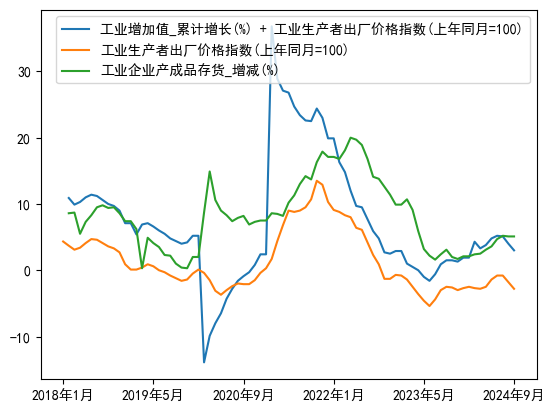

In [94]:
s1 = (gyzjzSeries + pmiSeries).ffill()
s2 = ccpSeries.ffill()
s3 = pmiSeries.ffill()
xtricks = range(0, s1.size, round(s1.size / 5))

fig = plt.figure()
ax = fig.gca()
ax.set_xticks(xtricks)
ax.plot(s1.index, s1, label="工业增加值_累计增长(%) + 工业生产者出厂价格指数(上年同月=100)")
ax.plot(s3.index, s3, label="工业生产者出厂价格指数(上年同月=100)")
ax.plot(s2.index, s2, label="工业企业产成品存货_增减(%)")
plt.legend()

ppi为负，名义工业增加值增速下降，但是存货增速没有下降，显示需求很低。

#### 价格影响

出场价格上涨，会提高企业盈利水平，从而带动工业生产

可以用ppi指代价格水平

#### 流动性影响

当流动性宽松的时候：1. 企业更容易融资；2. 刺激社会需求

用社会融资增速做对比分析

### 结构分析